# Mapa de tipologías de *slope units* — Valle de Aburrá

Este notebook genera un **mapa temático, listo para tesis**, de las tres tipologías de *slope units* (SU)
obtenidas en la clusterización GMM (`su_type` = 1, 2, 3), con:

- Leyenda en inglés con los tres tipos.
- Coordenadas en **grados y minutos**, mostradas **solo en el eje izquierdo (latitud) y el inferior (longitud)**.
- Flecha de norte y barra de escala.
- Paleta categórica segura para daltonismo (Okabe–Ito) y apta para impresión.

**Correspondencia `su_type` → tipología** (verificada con los centroides del GMM: pendiente y curvatura medias):

| `su_type` | Pendiente media | Curvatura media | Nombre (inglés) |
|:--:|:--:|:--:|:--|
| 1 | ~30° | ≈ 0 | **Steep concave–convex slopes** |
| 2 | ~17° | ≈ 0 | **Intermediate concave–convex slopes** |
| 3 | ~27.5° | −0.0018 (cóncava) | **Steep concave slopes** |

> ⚠️ El etiquetado del GMM es arbitrario entre corridas. Como tu `.gpkg` ya tiene los `su_type` fijados (1/2/3),
> el mapeo de arriba es válido. Si vuelves a correr la clusterización, **re-verifica los centroides** antes de confiar en los nombres.


## 1) Importaciones

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.9,
    "savefig.facecolor": "white",
})

## 2) Configuración

Ajusta aquí la ruta, la columna de tipología, los nombres y los colores.

In [43]:
# --- Entrada ---
PATH_SU = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg"
COL_SU  = "su_type"                 # columna entera con la tipología (1, 2, 3)

# --- Etiquetas (inglés) ---
SU_LABELS = {
    1: "Steep concave–convex slopes",
    2: "Intermediate concave–convex slopes",
    3: "Steep concave slopes",
}

# --- Colores categóricos (Okabe–Ito: seguros para daltonismo) ---
SU_COLORS = {1: "#E69F00", 2: "#009E73", 3: "#D81B60"}

# --- Salidas (para la tesis: PNG raster + PDF vectorial para LaTeX/Overleaf) ---
OUT_PNG = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/mapa_slope_units_aburra.png"
OUT_PDF = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/mapa_slope_units_aburra.pdf"

# --- Parámetros del mapa ---
TITULO     = "Types of Slope Units in the Aburrá Valley"
ESCALA_KM  = 5          # longitud de la barra de escala (km)
MOSTRAR_N  = False      # True -> agrega el conteo de SU a cada entrada de la leyenda

## 3) Carga, validación y reproyección a coordenadas geográficas

Reproyectamos a **EPSG:4326** para que los ejes queden en latitud/longitud (grados). El cálculo es independiente del CRS original del archivo.

In [3]:
gdf = gpd.read_file(PATH_SU)

# Validaciones mínimas
if COL_SU not in gdf.columns:
    raise KeyError(f"No existe la columna '{COL_SU}'. Columnas: {list(gdf.columns)}")
if gdf.crs is None:
    raise ValueError("La capa no tiene CRS definido; asígnalo antes de continuar.")

gdf = gdf[gdf[COL_SU].notna()].copy()
gdf[COL_SU] = gdf[COL_SU].astype(int)

# Reproyección a geográficas para ejes en grados
gdf_geo = gdf.to_crs(4326)

# Borde del área de estudio (disolviendo todas las SU)
borde = gdf_geo.dissolve().boundary

# Conteo por tipología (control)
conteo = gdf_geo[COL_SU].value_counts().sort_index()
print("CRS original:", gdf.crs.to_epsg(), "-> reproyectado a EPSG:4326")
print("Conteo de slope units por tipo:")
for k, v in conteo.items():
    print(f"  SU {k} ({SU_LABELS.get(k,'?')}): {v:,}")

CRS original: 3116 -> reproyectado a EPSG:4326
Conteo de slope units por tipo:
  SU 1 (Steep concave–convex slopes): 31,636
  SU 2 (Intermediate concave–convex slopes): 23,012
  SU 3 (Steep concave slopes): 6,594


## 4) Funciones auxiliares

Formateo de ticks en **grados-minutos**, selección de un paso de grilla "bonito", y dibujo de flecha de norte y barra de escala.

In [37]:
def formateador_dm(positivo: str, negativo: str) -> FuncFormatter:
    """Devuelve un FuncFormatter que muestra un valor decimal de grados
    como grados-minutos con hemisferio (p. ej. 6°24'N, 75°36'W)."""
    def _fmt(value, _pos):
        hemi = positivo if value >= 0 else negativo
        v = abs(value)
        d = int(v)
        m = (v - d) * 60.0
        if round(m) == 60:        # evita 75°60'
            d += 1; m = 0.0
        return f"{d}\u00b0{round(m):02d}'{hemi}"
    return FuncFormatter(_fmt)


def paso_bonito(span: float, n_ticks: int = 5) -> float:
    """Elige un intervalo de ticks 'redondo' (en grados) para ~n_ticks marcas."""
    raw = span / n_ticks
    for s in (0.05, 0.1, 0.2, 0.25, 0.5, 1.0):
        if raw <= s:
            return s
    return 1.0


def agregar_flecha_norte(ax):
    """Flecha de norte simple en la esquina superior derecha (coords de ejes)."""
    ax.annotate("N", xy=(0.06, 0.955), xytext=(0.06, 0.875),
                xycoords="axes fraction", textcoords="axes fraction",
                ha="center", va="center", fontsize=12, fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="#222222", lw=1.6))


def agregar_barra_escala(ax, bounds, km: float):
    """Barra de escala en km, convertida a grados a la latitud central
    (1° lon ≈ 111.320·cos(lat) km). Pensada para CRS geográfico de display."""
    minx, miny, maxx, maxy = bounds
    lat_c = (miny + maxy) / 2.0
    bar_deg = km / (111.320 * np.cos(np.deg2rad(lat_c)))
    x0 = minx + (maxx - minx) * 0.45
    y0 = miny + (maxy - miny) * 0.03
    tick_h = (maxy - miny) * 0.008
    ax.plot([x0, x0 + bar_deg], [y0, y0], color="#222222", lw=2.4, solid_capstyle="butt")
    ax.plot([x0, x0], [y0, y0 + tick_h], color="#222222", lw=2.4)
    ax.plot([x0 + bar_deg, x0 + bar_deg], [y0, y0 + tick_h], color="#222222", lw=2.4)
    ax.text(x0 + bar_deg / 2, y0 + tick_h * 1.6, f"{int(km)} km",
            ha="center", va="bottom", fontsize=8.5)


## 5) Función principal de mapeo

In [44]:
def plot_mapa_su(gdf_geo, borde, col_su, labels, colors, titulo,
                 escala_km=5, mostrar_n=False, figsize=(7.2, 8.6)):
    """Dibuja el mapa de tipologías de slope units en coordenadas geográficas.

    Parámetros
    ----------
    gdf_geo : GeoDataFrame en EPSG:4326 con la columna `col_su`.
    borde   : GeoSeries con el contorno del área de estudio.
    col_su  : nombre de la columna entera de tipología.
    labels  : dict {codigo: nombre en inglés}.
    colors  : dict {codigo: color hex}.
    titulo  : título del mapa.
    escala_km : longitud de la barra de escala (km).
    mostrar_n : si True, agrega el conteo a cada entrada de la leyenda.

    Retorna
    -------
    (fig, ax) de matplotlib.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=160)

    # Polígonos por tipología (orden ascendente, sin borde para no saturar)
    for k in sorted(labels):
        sub = gdf_geo[gdf_geo[col_su] == k]
        if len(sub):
            sub.plot(ax=ax, color=colors[k], linewidth=0, antialiased=True)

    #borde.plot(ax=ax, color="#333333", linewidth=0.8)

    # Límites + margen y aspecto geográfico correcto
    minx, miny, maxx, maxy = gdf_geo.total_bounds
    padx = (maxx - minx) * 0.04
    pady = (maxy - miny) * 0.04
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_aspect(1.0 / np.cos(np.deg2rad((miny + maxy) / 2)))

    # Ticks grados-minutos SOLO abajo (lon) e izquierda (lat)
    ax.xaxis.set_major_locator(MultipleLocator(paso_bonito(maxx - minx)))
    ax.yaxis.set_major_locator(MultipleLocator(paso_bonito(maxy - miny)))
    ax.xaxis.set_major_formatter(formateador_dm("E", "W"))
    ax.yaxis.set_major_formatter(formateador_dm("N", "S"))
    ax.tick_params(top=False, right=False, labeltop=False, labelright=False,
                   bottom=True, left=True, labelbottom=True, labelleft=True,
                   direction="out", length=4, labelsize=9)

    # Grilla sutil y marco en los 4 lados (caja de mapa)
    ax.grid(True, color="#BBBBBB", linewidth=0.4, linestyle=(0, (3, 3)), alpha=0.6)
    for s in ax.spines.values():
        s.set_edgecolor("#444444"); s.set_linewidth(0.9)

    #ax.set_xlabel("Longitude", fontsize=10, labelpad=6)
    #ax.set_ylabel("Latitude", fontsize=10, labelpad=6)
    ax.set_title(titulo, fontsize=12.5, fontweight="bold", pad=12)

    agregar_flecha_norte(ax)
    agregar_barra_escala(ax, (minx, miny, maxx, maxy), escala_km)

    # Leyenda
    conteo = gdf_geo[col_su].value_counts()
    handles = []
    for k in sorted(labels):
        txt = f"SU {k} \u2014 {labels[k]}"
        if mostrar_n:
            txt += f"  (n={int(conteo.get(k, 0)):,})"
        handles.append(Patch(facecolor=colors[k], edgecolor="none", label=txt))
    leg = ax.legend(handles=handles, title="Slope Unit type",
                        loc="center right", bbox_to_anchor=(0.995, 0.25),
                        frameon=True, fontsize=8.6, title_fontsize=9.4,
                        borderpad=0.7, labelspacing=0.6)
    leg.get_frame().set_edgecolor("#888888")
    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(0.92)

    fig.tight_layout()
    return fig, ax


## 6) Generar y guardar el mapa

Se guarda en **PNG** (raster, para vistas rápidas) y **PDF vectorial** (recomendado para incrustar en LaTeX/Overleaf con `\includegraphics`).

Guardado:
  /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/mapa_slope_units_aburra.png
  /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/mapa_slope_units_aburra.pdf


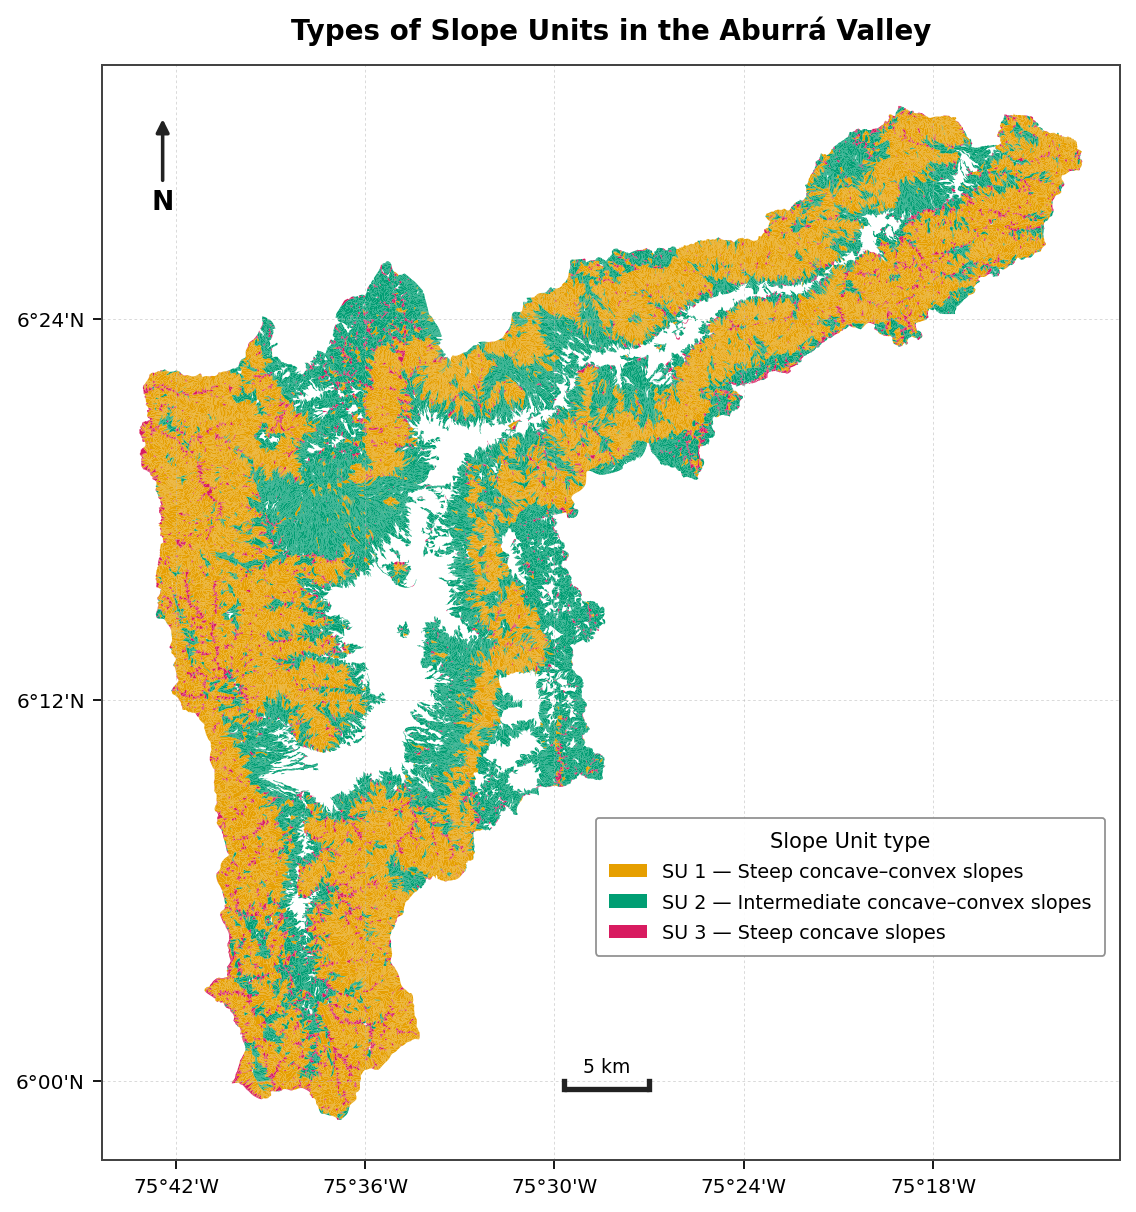

In [45]:
fig, ax = plot_mapa_su(
    gdf_geo, borde, COL_SU, SU_LABELS, SU_COLORS,
    titulo=TITULO, escala_km=ESCALA_KM, mostrar_n=MOSTRAR_N,
)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, bbox_inches="tight", facecolor="white")  # vectorial
print(f"Guardado:\n  {OUT_PNG}\n  {OUT_PDF}")
plt.show()